<a href="https://colab.research.google.com/github/AdiV121003/AI_SECURITY_EXPERIMENTS/blob/main/LoanApproval_DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loan Approval Decision Tree

The goal of this mini-project is to build a decision tree model that predicts loan approval based on numerous factors like credit score, defaults on file etc and to analyse the model's fairness, bias and potentional vulnerabilities.

# Step 1: Load Dataset

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier

In [12]:
data = pd.read_csv("/content/loan_data.csv")

# Step 2: Exploring Data

In [13]:
data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [15]:
data.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [16]:
#Check for Missing Values
print("Missing values count per column:")
print(data.isnull().sum())

#Check for Duplicate Rows
print(f"Number of duplicate rows: {data.duplicated().sum()}")


Missing values count per column:
person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64
Number of duplicate rows: 0


In [17]:
data['person_age'] = data['person_age'].astype('int')
data['person_age'].dtypes

dtype('int64')

In [18]:
data['loan_status'].value_counts() # 0 is rejected, 1 is approved

,count
loan_status,
0,35000
1,10000


The dataset seems to have 45000 non-null values and 14 columns. The target variable is Loan Status where the values are 0 for Rejected Loan and 1 for Approved Loan status. Thus, the dataset has more rejected applications data (35000) and only 10000 approved loan data.

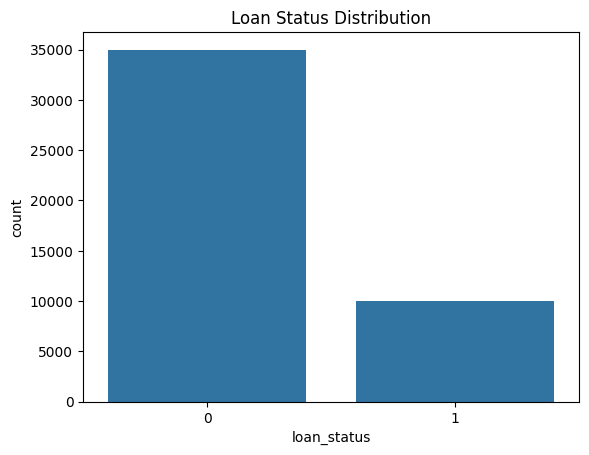

In [19]:
import seaborn as sns
sns.countplot(x='loan_status', data=data)
plt.title("Loan Status Distribution")
plt.show()

In [20]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'loan_status'],
      dtype='object')


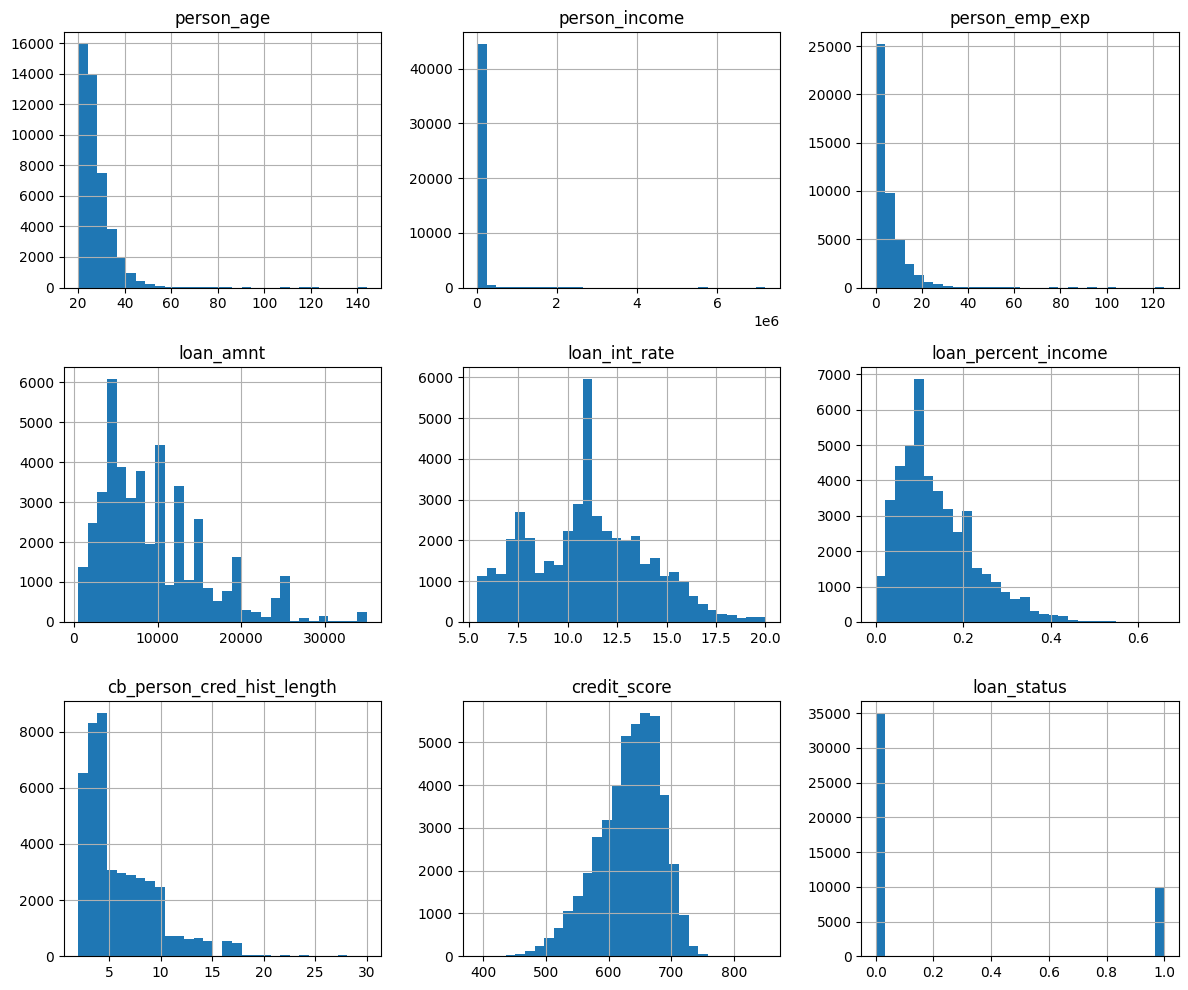

In [21]:
data[num_cols].hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()

In [22]:
categorical_cols_object = data.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols_object)

['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


In [23]:
#Categorical Columns
cat_cols = data.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='object')


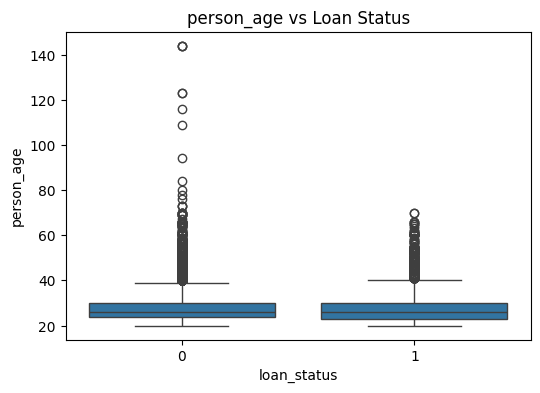

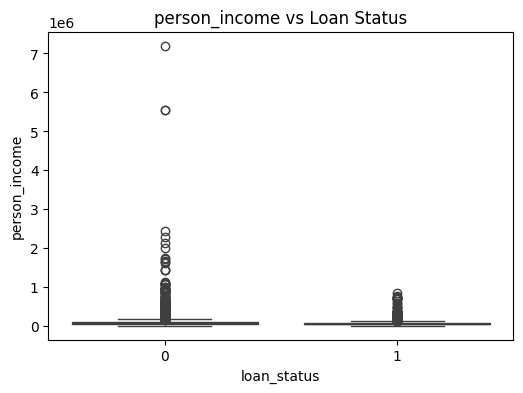

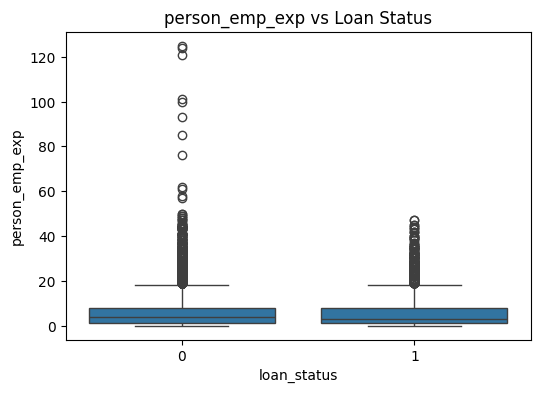

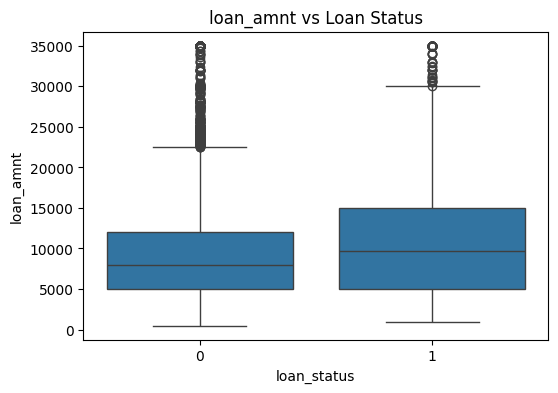

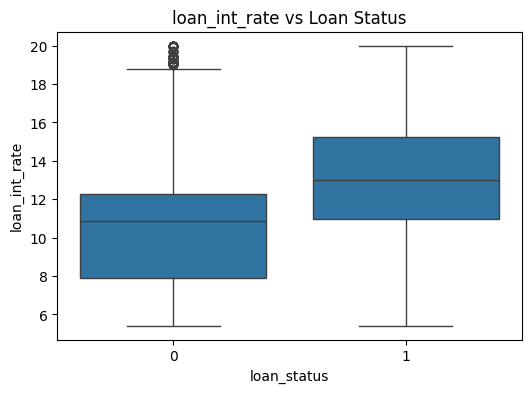

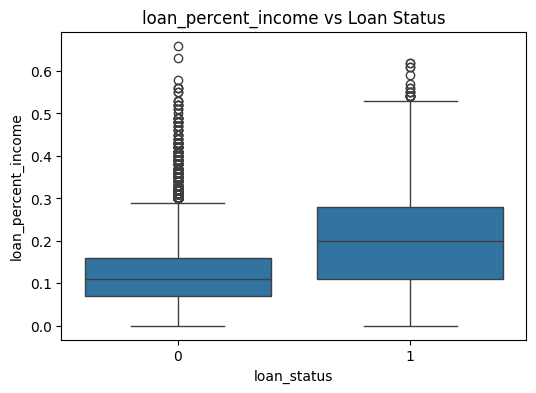

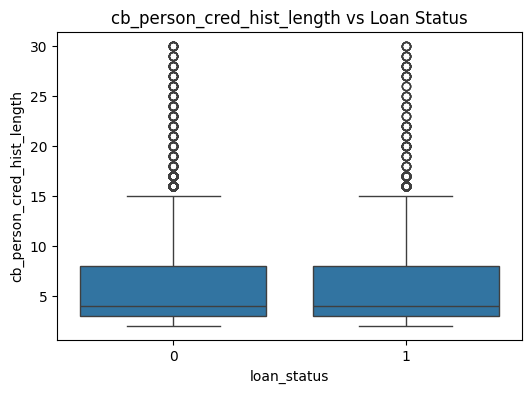

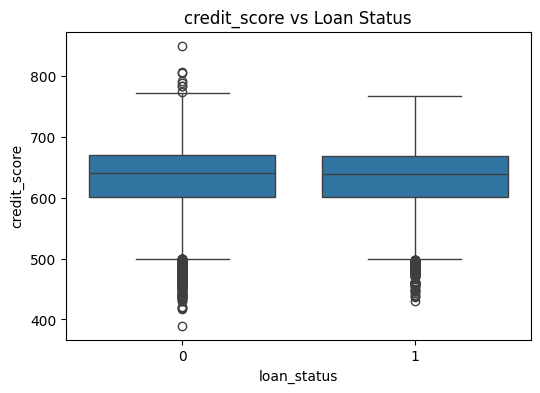

In [24]:
for col in num_cols:
    if col != 'loan_status':
        plt.figure(figsize=(6, 4))
        sns.boxplot(x='loan_status', y=col, data=data)
        plt.title(f"{col} vs Loan Status")
        plt.show()

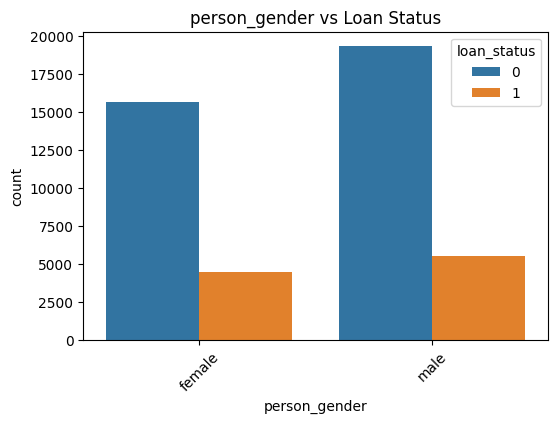

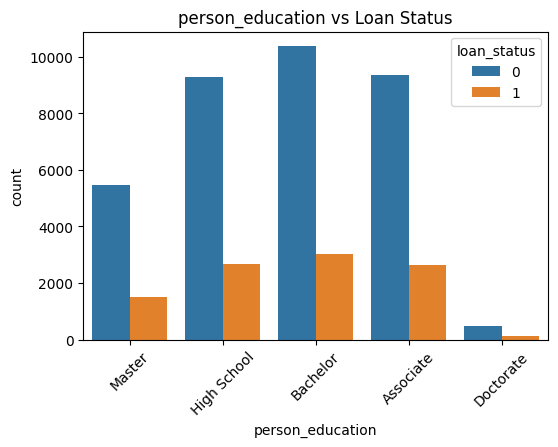

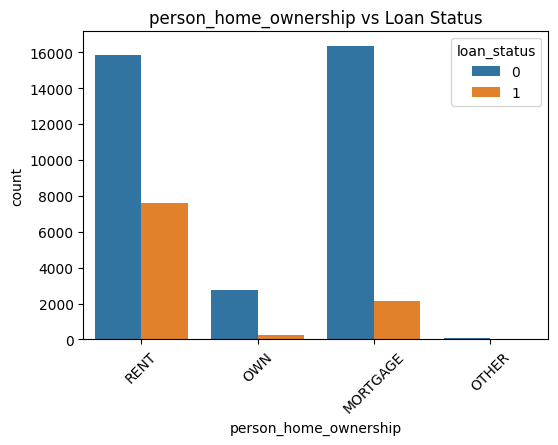

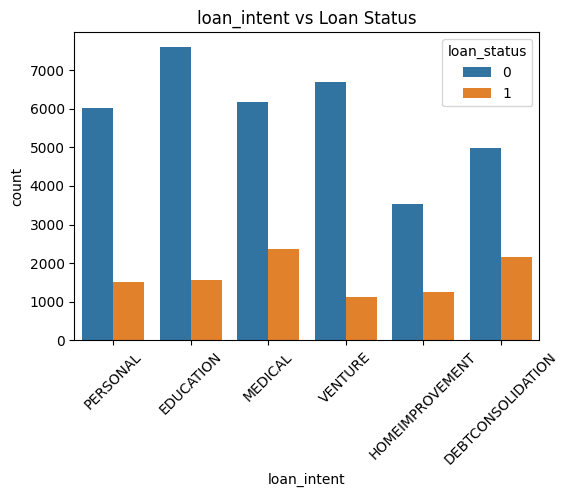

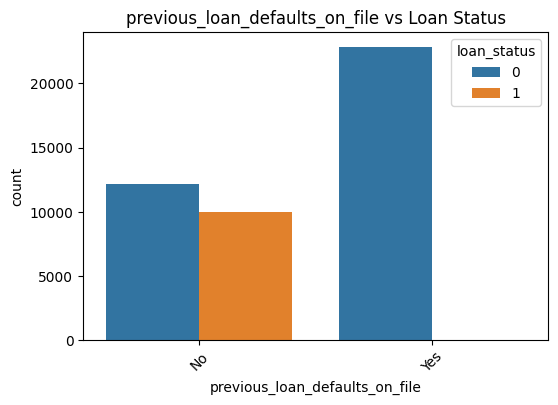

In [25]:
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue='loan_status', data=data)
    plt.title(f"{col} vs Loan Status")
    plt.xticks(rotation=45)
    plt.show()

In [26]:
#Approval Rate per Category
for col in cat_cols:
    print(f"\nApproval rate by {col}:")
    print(data.groupby(col)['loan_status'].mean()*100)


Approval rate by person_gender:
person_gender
female    22.248127
male      22.201200
Name: loan_status, dtype: float64

Approval rate by person_education:
person_education
Associate      22.031926
Bachelor       22.524069
Doctorate      22.866345
High School    22.310391
Master         21.762178
Name: loan_status, dtype: float64

Approval rate by person_home_ownership:
person_home_ownership
MORTGAGE    11.596084
OTHER       33.333333
OWN          7.522874
RENT        32.397731
Name: loan_status, dtype: float64

Approval rate by loan_intent:
loan_intent
DEBTCONSOLIDATION    30.272918
EDUCATION            16.956189
HOMEIMPROVEMENT      26.301484
MEDICAL              27.819373
PERSONAL             20.140360
VENTURE              14.426397
Name: loan_status, dtype: float64

Approval rate by previous_loan_defaults_on_file:
previous_loan_defaults_on_file
No     45.163039
Yes     0.000000
Name: loan_status, dtype: float64


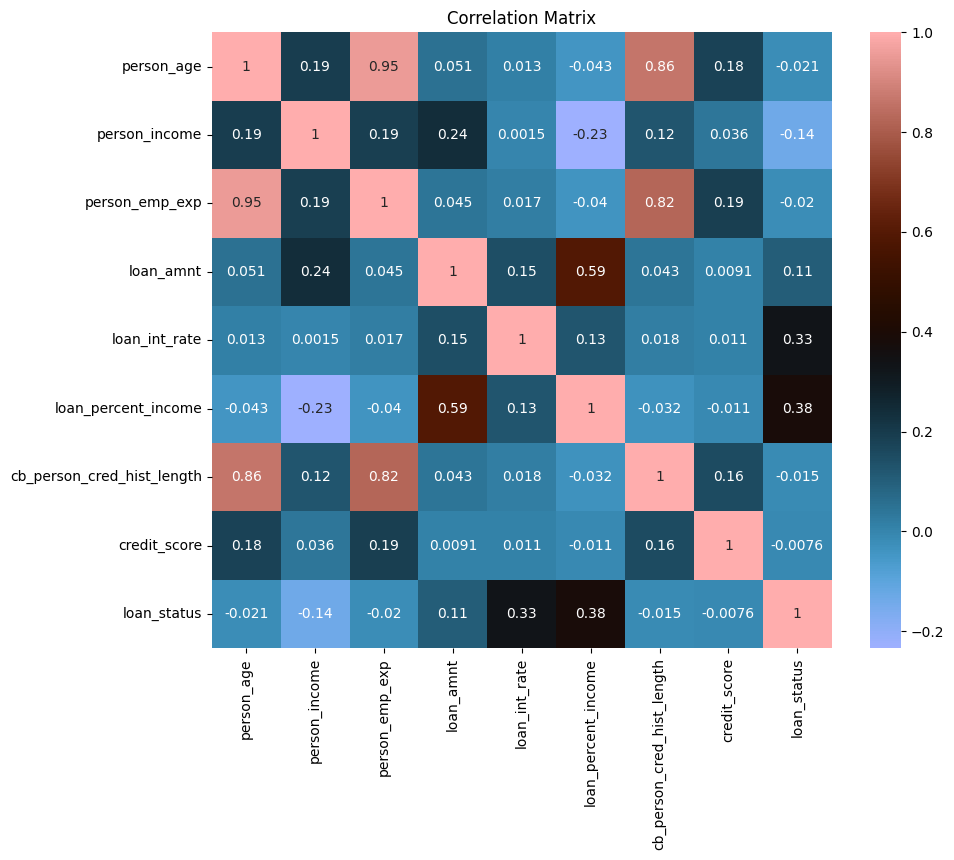

In [27]:
##Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data[num_cols].corr(), annot=True, cmap='berlin')
plt.title("Correlation Matrix")
plt.show()

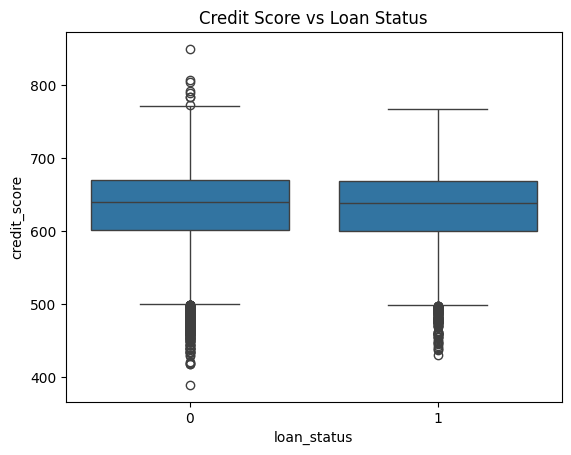

In [28]:
sns.boxplot(x='loan_status', y='credit_score', data=data)
plt.title("Credit Score vs Loan Status")
plt.show()

In [29]:
##Approval Rate by Age Group
data['age_group'] = pd.cut(data['person_age'], bins=[18,25,35,50,80])

data.groupby('age_group')['loan_status'].mean()

/tmp/ipykernel_520/3010445388.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('age_group')['loan_status'].mean()


,loan_status
age_group,
"(18, 25]",0.233942
"(25, 35]",0.213122
"(35, 50]",0.206109
"(50, 80]",0.260188


# Actionable Insights from EDA
* The visualization confirms the class imbalance.
* Also, there is strong multicollinearity in age, employment experience, and credit history length, thus there is redundancy as expected because employment experience and credit history length increases with increase in age. We can drop one of these correlated features.
* Loan_percent_income (debt-to-income ratio) and loan_int_rate show a strong relationship with loan approval status, showing that approval decisions are influenced by repayment burden and borrower's risk capacity.
* Income, loan amount, and employment experience are highly skewed and contain extreme outliers, requiring transformation or capping.
* Additionally, unrealistic values in age and experience indicate the need for data cleaning.

# Step 3: Data Cleaning

In [30]:
#Remove outliers from the highly skewed income variable
data['person_income'] = np.log1p(data['person_income'])

In [31]:
#Remove outliers in employment experience by capping the age
data = data[data['person_emp_exp'] <= 60]

In [32]:
#Remove outliers in age
data = data[(data['person_age'] >= 18) & (data['person_age'] <= 80)]

In [33]:
#Map education categorical values to numerical values
education_map = {
    'High School': 0,
    'Associate': 1,
    'Bachelor': 2,
    'Master': 3,
    'Doctorate': 4
}

data['person_education'] = data['person_education'].map(education_map)

In [34]:
#Encode Data
encoded_data = pd.get_dummies(data, drop_first=True)
encoded_data.columns

Index(['person_age', 'person_education', 'person_income', 'person_emp_exp',
       'loan_amnt', 'loan_int_rate', 'loan_percent_income',
       'cb_person_cred_hist_length', 'credit_score', 'loan_status',
       'person_gender_male', 'person_home_ownership_OTHER',
       'person_home_ownership_OWN', 'person_home_ownership_RENT',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'previous_loan_defaults_on_file_Yes', 'age_group_(25, 35]',
       'age_group_(35, 50]', 'age_group_(50, 80]'],
      dtype='object')

In [35]:
encoded_data = encoded_data.astype({col: 'int' for col in encoded_data.select_dtypes('bool').columns})

In [36]:
#For Fairness Analysis
age_groups = encoded_data[[
    'age_group_(25, 35]',
    'age_group_(35, 50]',
    'age_group_(50, 80]'
]]

gender = encoded_data['person_gender_male']

In [37]:
gender.head()

,person_gender_male
0,0
1,0
2,0
3,0
4,1


# Step 4: Decision Tree Modelling Without Age Feature



In [38]:
from sklearn.tree import DecisionTreeClassifier

X = encoded_data.drop(columns=[
    'loan_status',
    'age_group_(25, 35]',
    'age_group_(35, 50]',
    'age_group_(50, 80]'
])

y = encoded_data['loan_status']


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,      #keeps ratio of classes i.e target variables remains same
    random_state=42
)


In [40]:
dt = DecisionTreeClassifier(max_depth=6,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                       min_samples_leaf=20, min_samples_split=50,
                       random_state=42)

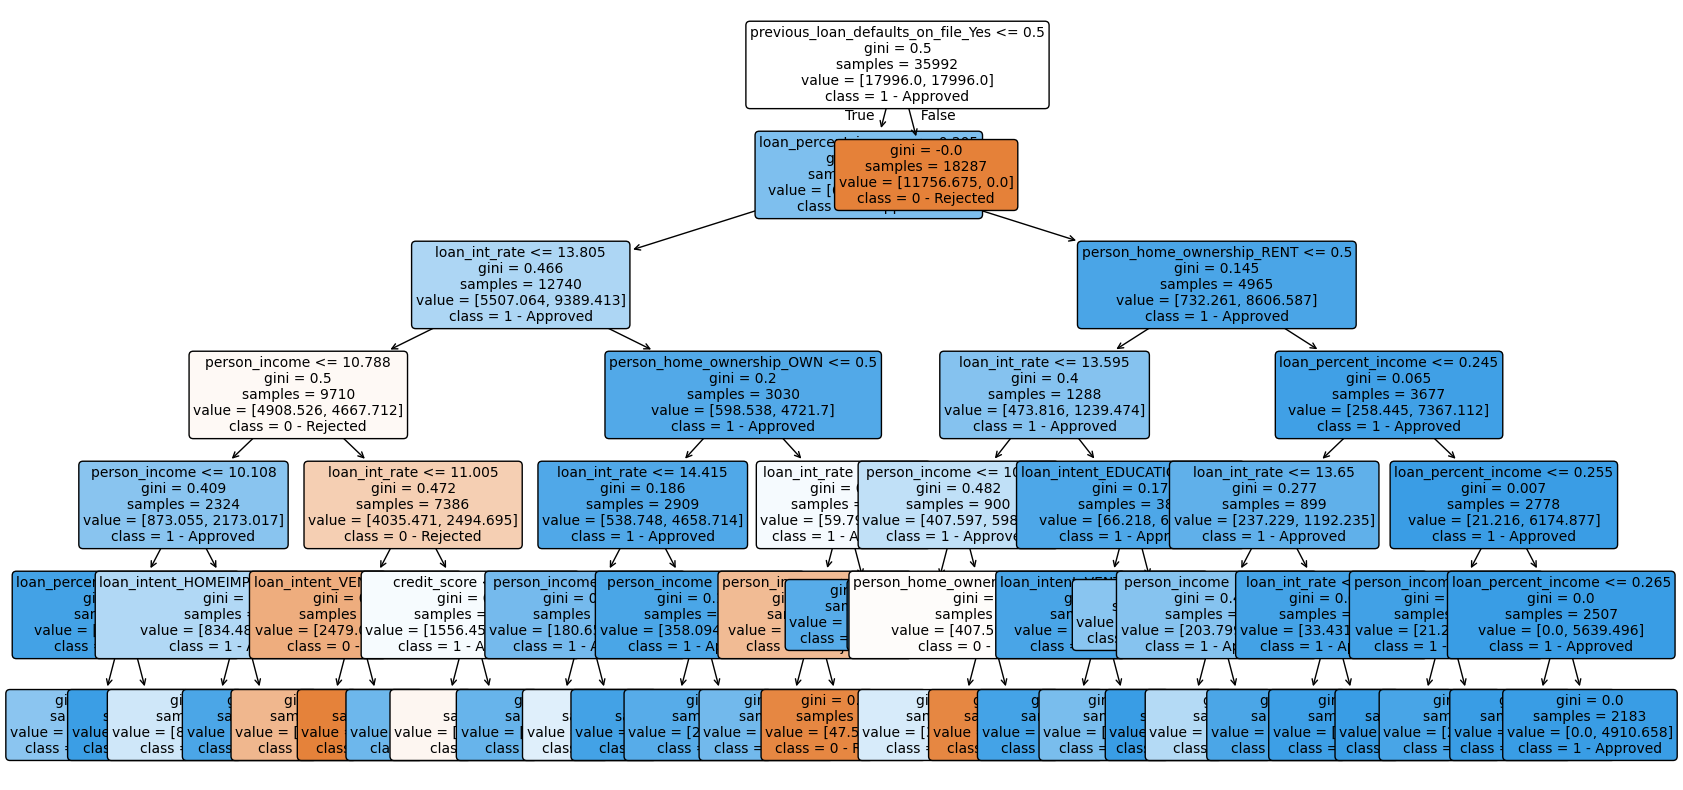

In [41]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=['0 - Rejected', '1 - Approved'],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.show()

In [42]:
from sklearn.metrics import classification_report

y_pred = dt.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.88      0.92      6998
           1       0.68      0.88      0.77      2000

    accuracy                           0.88      8998
   macro avg       0.82      0.88      0.85      8998
weighted avg       0.90      0.88      0.89      8998



In [43]:
import pandas as pd

importance = pd.Series(
    dt.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(10))

previous_loan_defaults_on_file_Yes    0.700667
loan_int_rate                         0.117895
loan_percent_income                   0.084420
person_income                         0.061320
person_home_ownership_RENT            0.013223
person_home_ownership_OWN             0.006445
loan_intent_VENTURE                   0.005815
loan_intent_HOMEIMPROVEMENT           0.005621
credit_score                          0.004191
loan_intent_EDUCATION                 0.000402
dtype: float64


In [44]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, dt.predict(X_train))
test_acc = accuracy_score(y_test, dt.predict(X_test))

print(train_acc, test_acc)

0.8801955990220048 0.8828628584129806


# Step 5: Decision Tree Modelling With Age


In [45]:
X_2 = encoded_data.drop('loan_status',axis=1)
y_2 = encoded_data['loan_status']

In [46]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_2, y_2,
    test_size=0.2,
    stratify=y_2,
    random_state=42
)


In [47]:
dt2 = DecisionTreeClassifier(max_depth=6,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

dt2.fit(X_train2, y_train2)

DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                       min_samples_leaf=20, min_samples_split=50,
                       random_state=42)

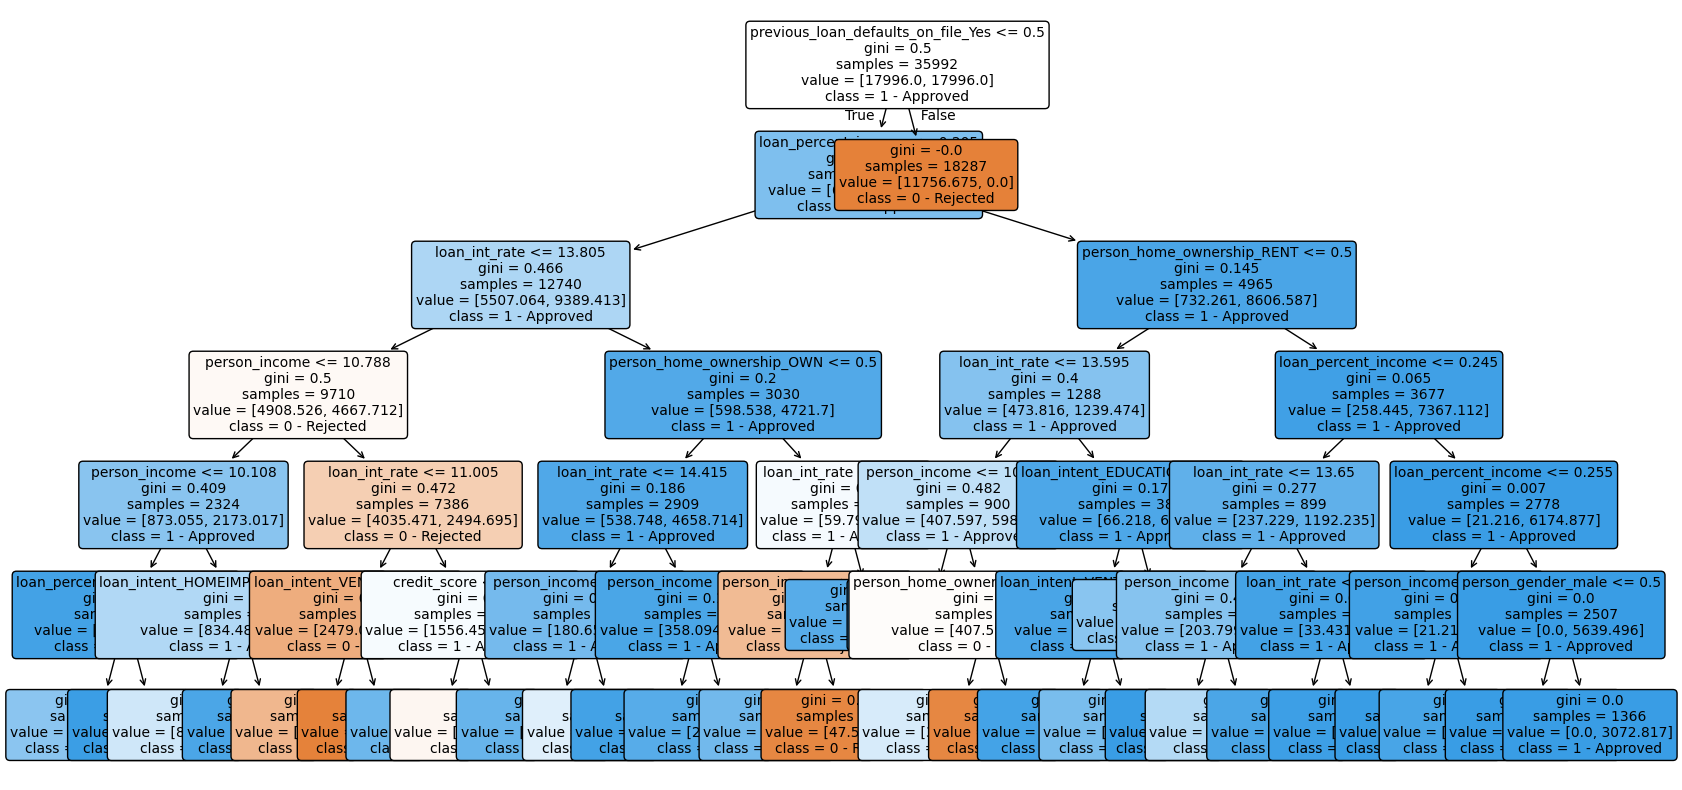

In [48]:
plt.figure(figsize=(20, 10))  # Make it large enough to read
plot_tree(
    dt2,
    feature_names=X_2.columns,
    class_names=['0 - Rejected', '1 - Approved'],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.show()

In [49]:
print("Train:", accuracy_score(y_2, dt2.predict(X_2)))
print("Test:", accuracy_score(y_2, dt2.predict(X_2)))

Train: 0.8807290509002
Test: 0.8807290509002


In [50]:
important_features = pd.Series(
    dt2.feature_importances_,
    index=X_2.columns
).sort_values(ascending=False)


In [51]:
print(important_features.head(11))

previous_loan_defaults_on_file_Yes    7.006674e-01
loan_int_rate                         1.178952e-01
loan_percent_income                   8.442006e-02
person_income                         6.132029e-02
person_home_ownership_RENT            1.322331e-02
person_home_ownership_OWN             6.445158e-03
loan_intent_VENTURE                   5.814841e-03
loan_intent_HOMEIMPROVEMENT           5.621075e-03
credit_score                          4.190947e-03
loan_intent_EDUCATION                 4.017590e-04
person_gender_male                    2.512585e-16
dtype: float64


In [52]:
not_important_features = pd.Series(
    dt2.feature_importances_,
    index=X_2.columns
).sort_values(ascending=True)
print(not_important_features.head(11))

person_age                     0.0
person_education               0.0
person_emp_exp                 0.0
loan_amnt                      0.0
cb_person_cred_hist_length     0.0
person_home_ownership_OTHER    0.0
loan_intent_MEDICAL            0.0
loan_intent_PERSONAL           0.0
age_group_(35, 50]             0.0
age_group_(50, 80]             0.0
age_group_(25, 35]             0.0
dtype: float64


In [53]:
X_2.shape

(44990, 22)

#Conclusion
The model relies heavily on financial risk-related variables when predicting loan approval. Previous loan defaults on file emerged influences the model the most. Even one default and the model discards the application. Other moderately important features are loan interest rate, loan percent income, and applicant income. vVariables such as age, employment experience, loan amount, and several categorical attributes had very little influence on the model’s predictions. This suggests that the model prioritizes indicators of credit risk rather than demographic attributes when making decisions.

# Fairness Audit

Two decision tree models were trained: one including age and one excluding age. Since both models achieved similar performance and age was not an important feature in the decision process, fairness analysis was conducted on the model without age to evaluate whether indirect bias still exists through correlated features.

In [54]:
results = X_test.copy()
results['actual'] = y_test
results['predicted'] = dt.predict(X_test)

In [55]:
results['age_group'] = data.loc[results.index, 'age_group']
approval_rate = results.groupby('age_group')['predicted'].mean()
print(approval_rate)
gap = approval_rate.max() - approval_rate.min()
print(gap)

age_group
(18, 25]    0.296565
(25, 35]    0.276622
(35, 50]    0.282528
(50, 80]    0.393939
Name: predicted, dtype: float64
0.1173169935384919


/tmp/ipykernel_520/3787878297.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approval_rate = results.groupby('age_group')['predicted'].mean()


In [56]:
#If someone actually deserves approval, does the model approve them equally across age groups?
from sklearn.metrics import recall_score

tpr_by_group = {}

for group in results['age_group'].unique():
    subset = results[results['age_group'] == group]
    tpr = recall_score(subset['actual'], subset['predicted'])
    tpr_by_group[group] = tpr

print(tpr_by_group)

{Interval(25, 35, closed='right'): 0.8816568047337278, Interval(18, 25, closed='right'): 0.8845360824742268, Interval(35, 50, closed='right'): 0.8719512195121951, Interval(50, 80, closed='right'): 0.9047619047619048}


Older applicants (50–80) are approved much more often. Although the decision tree model does not explicitly use age as a feature, differences in approval rates across age groups indicate potential indirect bias. Older applicants appear to receive approvals more frequently, which may result from correlated financial features such as income, credit history, or loan characteristics.

In [57]:
#Approval Rate by Gender
results_gender = X_test.copy()
results_gender['actual'] = y_test
results_gender['predicted'] = dt.predict(X_test)
results_gender['gender'] = data.loc[X_test.index, 'person_gender']

results_gender.groupby('gender')['predicted'].mean()

,predicted
gender,
female,0.285106
male,0.288827


In [58]:
approval_rate_gender = results_gender.groupby('gender')['predicted'].mean()
approval_gap_gender = approval_rate_gender.max() - approval_rate_gender.min()
print(approval_gap_gender)

0.0037203209988900254


In [59]:
#TPR by Gender
tpr_gender = {}

for g in results_gender['gender'].unique():
    subset = results_gender[results_gender['gender'] == g]
    tpr_gender[g] = recall_score(subset['actual'], subset['predicted'])

print(tpr_gender)

{'male': 0.8833922261484098, 'female': 0.881336405529954}


In [62]:
from sklearn.metrics import confusion_matrix

fpr_gender = {}

for g in results_gender['gender'].unique():
    subset = results_gender[results_gender['gender'] == g]
    tn, fp, fn, tp = confusion_matrix(subset['actual'], subset['predicted']).ravel()
    fpr_gender[g] = fp / (fp + tn)

print(fpr_gender)

{'male': np.float64(0.11495737535520538), 'female': np.float64(0.11960345378957467)}


In [63]:
#Approval Rate by Education Level
results_education_level = X_test.copy()
results_education_level['actual'] = y_test
results_education_level['predicted'] = dt.predict(X_test)
results_education_level['education_level'] = data.loc[X_test.index, 'person_education']

results_education_level.groupby('education_level')['predicted'].mean()

,predicted
education_level,
0,0.269921
1,0.291282
2,0.297738
3,0.286322
4,0.327103


##Fairness Analysis Conclusion:

The model has minimal disparity across gender, with approval rates for male and female applicants being nearly identical. Similarly, variations across education levels were moderate and reflect underlying financial characteristics associated with education levels rather than direct bias.

However, a noticeable difference was observed across age groups, where applicants in the 50–80 range had a higher approval rate compared to younger groups. These differences may arise indirectly through correlated financial variables such as income or credit history.

Overall, the model appears relatively balanced across most groups, but the age-related variation suggests the presence of potential indirect bias.

#Ethical Perspective
From an ethical perspective, the results show important ethical concerns that occur when deploying ML systems in decision-making areas. Even when sensitive attributes like age are removed from the model, it performs similarly which is good that it doesn't take up age considerations but disparities in loan approval rate can still emerge due to indirect, proxy variables that capture similar information. Thus we must be aware of occurence of indirect bias and potential discrimination while designing AI systems. We must try to reduce this bias that can occur from careless design of AI systems and make AI fairer. Also, while implementing AI systems in sensitive areas for decision-making, we must be aware of which features are considered important in the model's decision-making process and ensure it relies with the company's policies. Else, the AI-approval system might become too objective and inhumane. For example: The above model places "previous loan defaults" as a strong variable to make loan approval decisions, so even for one loan_default, it rejects the application. The company may have a more humane and lenient policy on this. Thus, ensure the decision-making process of the ML model aligns with the company's policies.

# Security Issues & Vulnerability Assessment

#### Threat Modelling
Potential attacker: Applicant manipulating loan
data

Attack surface: Input features

Goal: Increase loan approval probability

Weak point: Default features

In [66]:
#Feature Manipulation Test
changed = 0

for i in range(100):
    sample = X_test.iloc[i].copy()
    original = dt.predict([sample])[0]

    sample['previous_loan_defaults_on_file_Yes'] = 1 - sample['previous_loan_defaults_on_file_Yes']
    new_pred = dt.predict([sample])[0]

    if original != new_pred:
        changed += 1

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local

In [67]:
print("Predictions changed:", changed)

Predictions changed: 49


In [88]:
#Feature Manipulation Test
sample_2 = X_test.iloc[1].copy()
print("Original prediction for sample_2:", dt.predict([sample_2])[0])
sample_2['previous_loan_defaults_on_file_Yes'] = 1 - sample_2['previous_loan_defaults_on_file_Yes']
print("Prediction after negating loan defaults for sample_2:", dt.predict([sample_2])[0])

Original prediction for sample_2: 1
Prediction after negating loan defaults for sample_2: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


The above test shows that almost half of the tested predictions changed when the "previous loan defaults" feature was altered. Thus the model is highly sensitive to this feature, indicating a potential vulnerability if the input data is manipulated.

In [89]:
#Model Fragility

X_no_default = X.drop(columns=['previous_loan_defaults_on_file_Yes'])

from sklearn.model_selection import train_test_split

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_no_default, y, test_size=0.2, random_state=42
)

dt3 = DecisionTreeClassifier(max_depth=6, random_state=42)
dt3.fit(X_train3, y_train3)

from sklearn.metrics import accuracy_score

print("Accuracy without dominant feature:", accuracy_score(y_test3, dt3.predict(X_test3)))

Accuracy without dominant feature: 0.8909757723938653


Removing the dominant, most important "previous loan default" feature did not reduce model accuracy, meaning that other features in the dataset still contribute to the prediction process. But the above feature manipulation test shows that the model is still sensitive to the dominant feature. So if an attacker gets to know the importance of that feature, they can manipulate the input and manipulate the model into approving/rejecting the loan.

In [95]:
#Input Manipulation Test
sample3 = X_test.iloc[10].copy()

print("Original prediction:", dt.predict([sample3])[0])

sample3['person_income'] *= 1.1  # increase by 10%

print("Prediction after income change:", dt.predict([sample3])[0])

Original prediction: 0
Prediction after income change: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


I tried various input changes but the predictions did not change. The input sensitivity experiment showed that small changes in numeric inputs did not immediately change predictions. This is expected for decision tree models, where predictions change only when input values cross decision thresholds. (This may not be the case in continuous/linear models like logistic regression, SVM, neural networks or linear regression models. I will test these models next 👀)